# Minicurso 2: Aprendizado Federado Veicular: da Teoria a Prática

Este notebook implementa o código utilizado na atividade prática do minicurso do SBRC 2026.

## Bibliotecas e módulos necessários para a execução da atividade prática do minicurso

In [1]:
%cd ..

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026


/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import flwr as fl
import torch
import os

from flwr.common import ndarrays_to_parameters
from collections import OrderedDict
from IPython.display import Image

from utils.data.split_data import generate_datasets
from utils.visualization.distribution import distribution_plot
from architectures.torch.implementation import build_model
from utils.torch.load_federated_data import load_data_client
from utils.torch.utils import create_logger_client
from utils.utils import load_config
from architectures.torch.implementation import get_weights

from architectures.torch.implementation import build_model
from architectures.torch.implementation import (
    train, 
    evaluate,
)

/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyl

## Carregar os parâmetros presentes no arquivo de configurações do sistema

In [3]:
cfg = load_config("configs/config.yaml")

## 1 - Definição do ambiente federado

In [4]:
dataset_name=cfg['simulation']['data']['name']
alpha=cfg['simulation']['data']['alpha']
n_clients=cfg['simulation']['cars']
speeds=cfg['simulation']['speed']['index']

## 2 - Modelagem da heterogeneidade de clientes

### 2.1 - Heterogenidade de Dados

#### Gerando da distribuição com o valor de alfa igual a 100

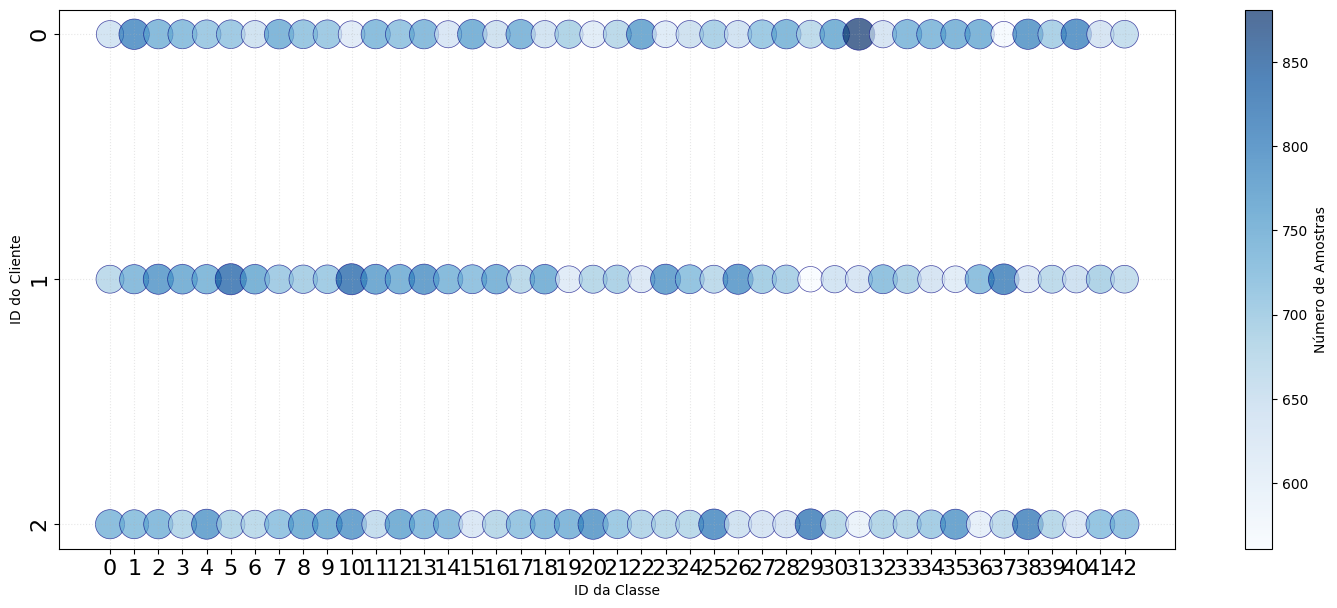

In [5]:
generate_datasets(dataset_name=dataset_name,
                  alpha=100,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 5

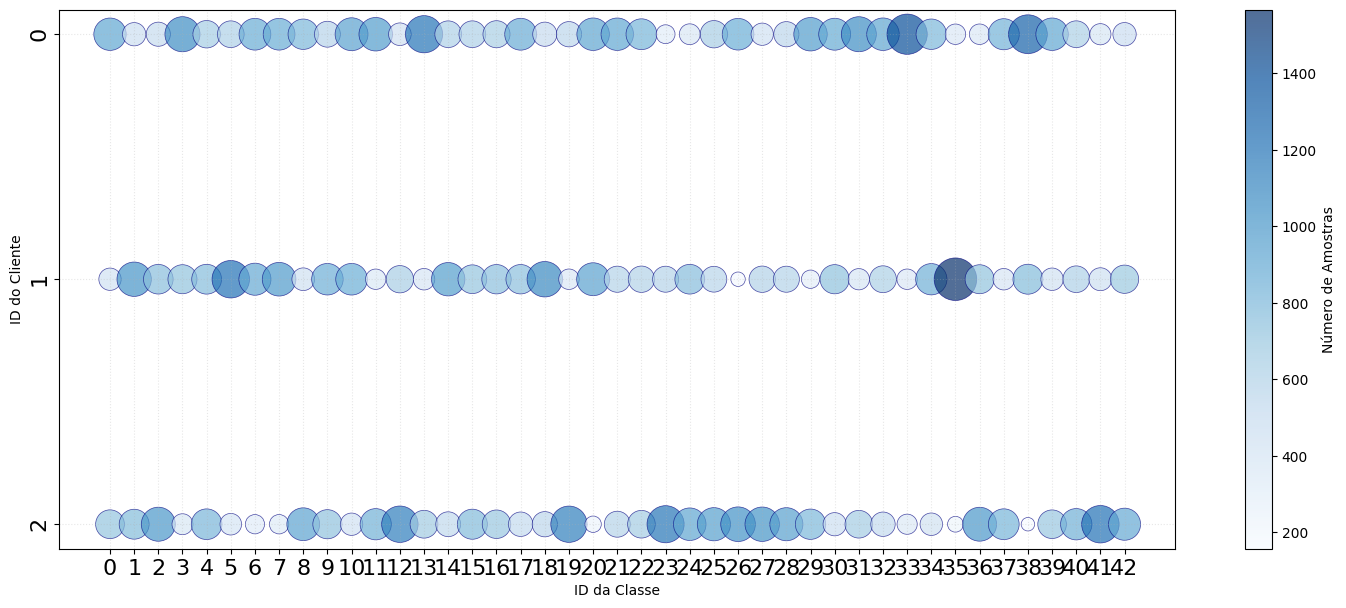

In [6]:
generate_datasets(dataset_name=dataset_name,
                  alpha=5.0,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 0.1

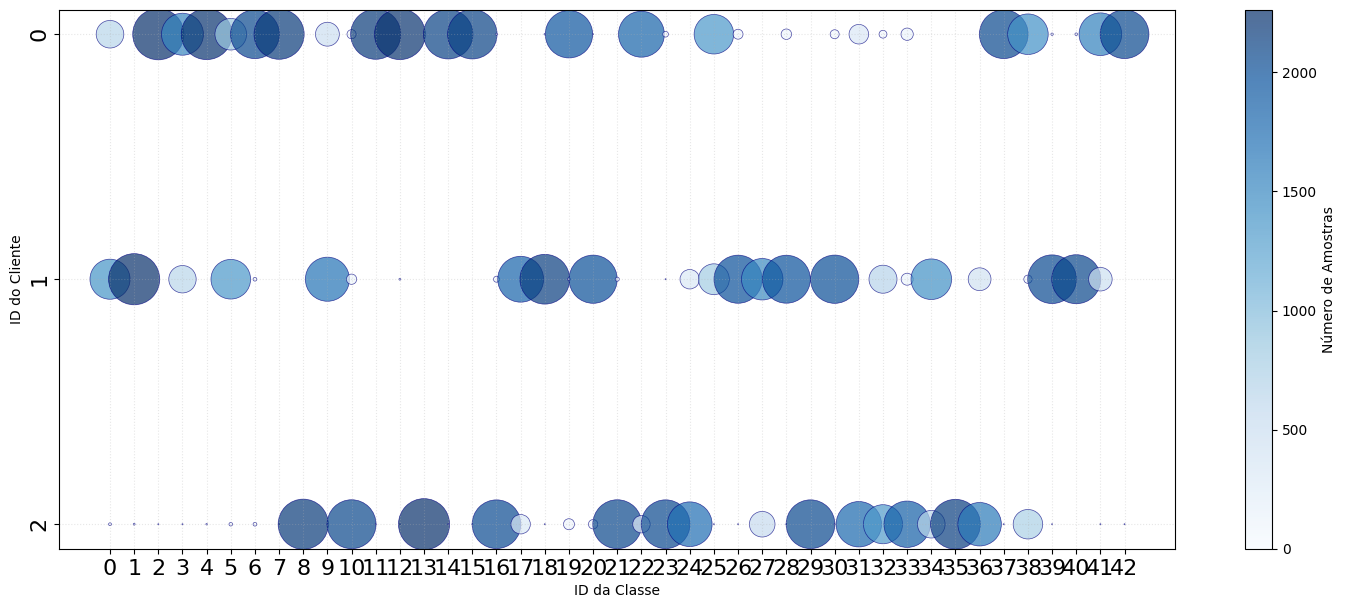

In [7]:
generate_datasets(dataset_name=dataset_name,
                  alpha=0.1,
                  n_clients=n_clients)

### 2.2 - Heterogenidade de Dispositivo 

## 3 - Simulação da mobilidade de veículos com o SUMO

### Criação dos diretórios

In [8]:
!source scripts/build/paths.sh

/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1659488) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


### Geração do modelo de mobilidade

In [9]:
!source scripts/run/raw/mobility.sh

PHASE 1 -> Generating the grid topology
Success.
....... -> Copy netfile to the current directory 
....... -> Generate continuous rerouters 
....... -> Generating random flows for JTRROUTER 
....... -> Run SUMO for configuration Krauss 3 cars / iteration 0
....... -> Generate tr file for configuration 3 cars / iteration 0
One or more coordinates are negative, some applications might need strictly positive values. To avoid this use the option --shift.
PHASE 1 -> Generating the grid topology
Success.
....... -> Copy netfile to the current directory 
....... -> Generate continuous rerouters 
....... -> Generating random flows for JTRROUTER 
....... -> Run SUMO for configuration Krauss 3 cars / iteration 1
....... -> Generate tr file for configuration 3 cars / iteration 1
One or more coordinates are negative, some applications might need strictly positive values. To avoid this use the option --shift.
PHASE 1 -> Generating the grid topology
Success.
....... -> Copy netfile to the current di

### Visualização do modelo de mobilidade gerado

### Geração de dados pre-processados para o modelo de comunicação

In [10]:
!source scripts/run/processed/mobility.sh

process finished


### Visualização dos dados de comunicação processados

## 4 - Simulação da comunicação

### Geração dos dados brutos de comunicação a partir do modelo de canal e do padrão de mobilidade fornecidos

In [11]:
!source scripts/run/raw/communication.sh

processing mobility file  1
processing mobility file  0
index  0
index  0
processing mobility file  2
index  0
processing mobility file  2
index  1
processing mobility file  0
index  1
processing mobility file  1
index  1
processing mobility file  0
index  2
processing mobility file  1
index  2
processing mobility file  2
index  2
process finished


### Processamento dos dados brutos de comunicação para utilizá-los no aprendizado federado

In [12]:
!source scripts/run/processed/communication.sh

processing file  0
processing file  2
processing file  1
processing finished
processing finished
processing finished
process finished


### Geração da figura para a visualização

In [13]:
!source scripts/visualize/throughput.sh

Figure(640x480)


### Visualização dos resultados do canal de comunicação 

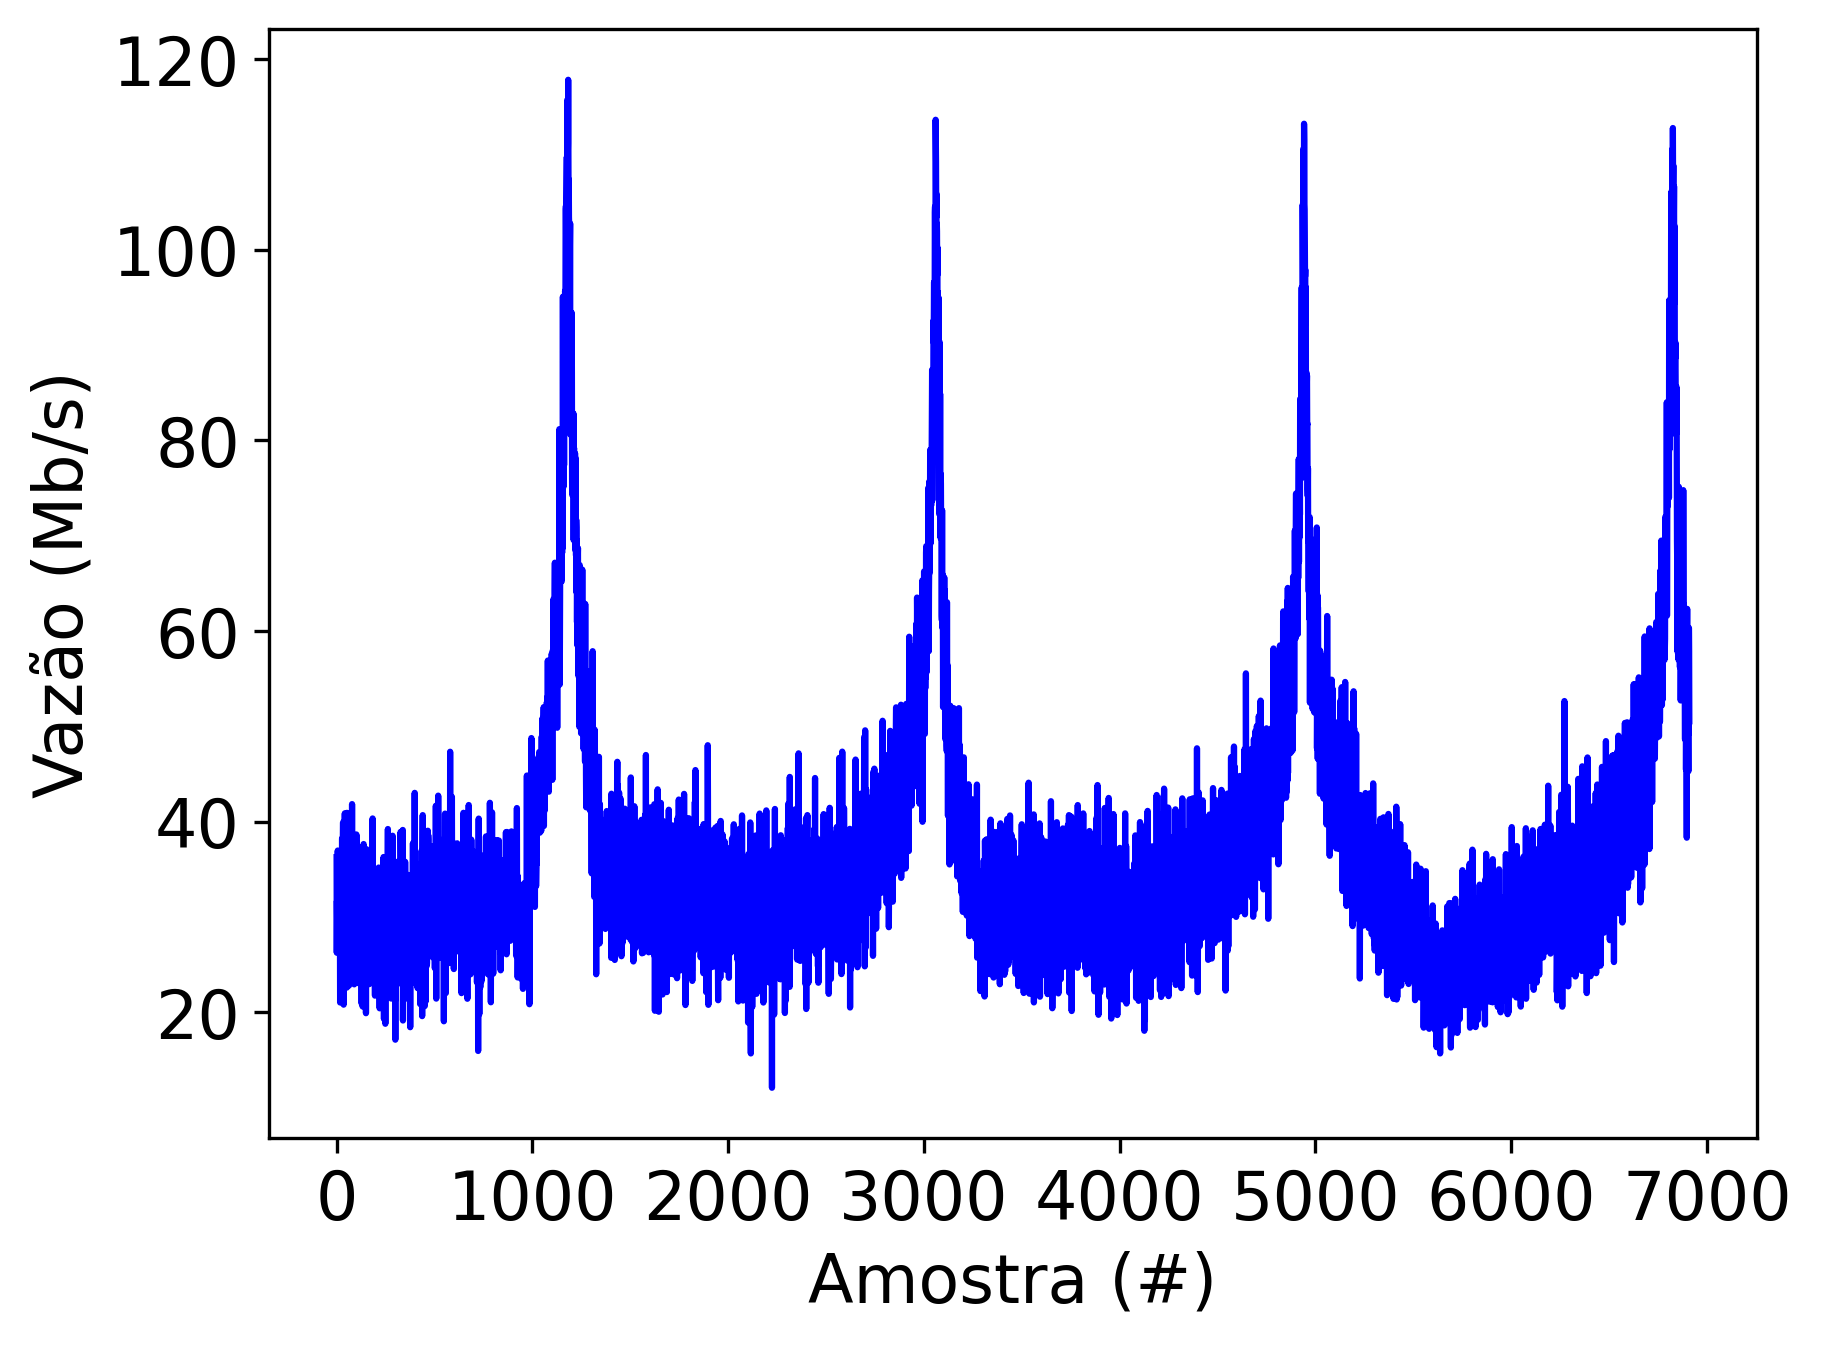

In [14]:
Image(filename=f'figures/communication/speed{speeds[0]}_pt.png')

## 5 - Adaptação do arcabouço Flower para o treinamento federado veicular

### Preparação do Ambiente Federado Veicular

#### Criando o cliente do aprendizado federado

In [15]:
class FLClient(fl.client.NumPyClient):

    def __init__(self, 
                 *args,
                 cid=-1,
                 model=None,
                 i_epochs=5,
                 model_name="MOBILENET",
                 batch_size=32,
                 dataset="CIFAR-10",
                 strategy="fedavg",
                 model_path="",
                 result_path="",
                 computation_time_path="",
                 logger=None,
                 optimizer=None,
                 criterion=None,
                 scheduler=None,
                 device=None,
                 trainloader=None,
                 testloader=None,
                 **kwargs):
        
        # paths
        self.strategy = strategy
        self.dataset = dataset
        self.model_name = model_name
        self.model_path = model_path+model_name+'/'
        self.result_path = result_path+model_name+'/'
        self.time_path = computation_time_path+model_name+'/'
        self.logger = logger
        self.global_epoch = 0
        
        # identifiers
        self.cid = cid

        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device

        # client's data
        self.trainloader = trainloader 
        self.testloader = testloader 
        self.train_size = len(trainloader.dataset)
        self.test_size = len(testloader.dataset)

        # learning parameters
        self.i_epochs = i_epochs
        self.bs = batch_size

    def get_weights(self):
        
        result = [val.cpu().numpy() for _, val in self.model.state_dict().items()]

        return result
        
    def set_weights(self, 
                    parameters):
    
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)


    def get_properties(self, 
                       config):

        return {'cid': self.cid}

    def fit(self, 
            parameters, 
            config):
        
        self.logger.debug("updating model parameters")
        self.set_weights(parameters)

        self.logger.debug("training model")
        loss = train(self.model, 
                     self.i_epochs, 
                     self.optimizer, 
                     self.criterion,
                     self.scheduler,
                     self.device,
                     self.trainloader,
                     self.logger)

        self.logger.debug("determine client's computational time")
        # TODO: implement the loading time here

        self.logger.debug("determine client's communication time")
        # TODO: implement the loading time here
        
        self.logger.debug(f'sending parameters to server: model_weights, len(train): {self.train_size}')
        return self.get_weights(), len(self.trainloader.dataset), {'loss':loss, "cid":self.cid}

    def evaluate(self, 
                 parameters, 
                 config):
        
        self.logger.debug(f'evaluating model')  
        
        self.logger.debug("updating model parameters")
        self.set_weights(parameters)
 
        self.logger.debug("evaluating model")
        accuracy, loss = evaluate(self.model,
                                  self.device,
                                  self.criterion,
                                  self.testloader,
                                  self.logger)

        self.logger.debug(f'sending parameters to server: loss {loss}, len(test): {self.test_size} accuracy: {float(accuracy)}')
        return loss, self.test_size, {"accuracy": float(accuracy), "cid":self.cid}



#### Configurando clientes

##### Cliente 1

In [21]:
client_id_1 = 1
i_epochs = cfg['simulation']['federated_learning']['client']['local_epochs']
bs = 32
ts = 0.2
SERVER_IP = cfg['simulation']['federated_learning']['server']['ip']
SERVER_PORT = cfg['simulation']['federated_learning']['server']['port']
DATASET = cfg['simulation']['data']['name']
LOG_PATH = 'logs/clients/flwr/'
IMAGE_DATA = 1
MODEL = cfg['simulation']['model']['name']
num_clients = cfg['simulation']['cars']
num_selected_clients = cfg['simulation']['federated_learning']['server']['n_clients_selected']
alpha = cfg['simulation']['data']['alpha']
strategy = cfg['simulation']['federated_learning']['server']['strategy']


logger = create_logger_client(LOG_PATH+MODEL+'/', 
                              client_id_1)

message_length = 800 * 1024 * 1024

logger.debug("Loading dataset")
train_dataset_1, test_dataset_1 = load_data_client(dataset_name=DATASET, 
                                               clientID=client_id_1, 
                                               numClients=num_clients, 
                                               alpha=alpha,
                                               trPer=ts,
                                               distribution="dirichlet") 

trainloader_1 = torch.utils.data.DataLoader(train_dataset_1, 
                                            batch_size=bs, 
                                            shuffle=True,
                                            num_workers=0,
                                            pin_memory=True)

testloader_1 = torch.utils.data.DataLoader(test_dataset_1, 
                                           batch_size=bs, 
                                           shuffle=True,
                                           num_workers=0,
                                           pin_memory=True)

logger.debug("Building model")

labels = cfg['simulation']['data']['n_classes']
features_shape = int(cfg['simulation']['data']['shape'][-1])

model_1, criterion_1, optimizer_1, device_1, scheduler_1 = build_model(features_shape=features_shape,
                                                                       labels_shape=labels,
                                                                       model_name=MODEL,
                                                                       lr=0.1)    

##### Client 2

In [ ]:
client_id_2 = 2

logger = create_logger_client(LOG_PATH+MODEL+'/', 
                              client_id_2)

logger.debug("Loading dataset")
train_dataset_2, test_dataset_2 = load_data_client(dataset_name=DATASET, 
                                               clientID=client_id_2, 
                                               numClients=num_clients, 
                                               alpha=alpha,
                                               trPer=ts,
                                               distribution="dirichlet") 

trainloader_2 = torch.utils.data.DataLoader(train_dataset_2, 
                                            batch_size=bs, 
                                            shuffle=True,
                                            num_workers=0,
                                            pin_memory=True)

testloader_2 = torch.utils.data.DataLoader(test_dataset_2, 
                                           batch_size=bs, 
                                           shuffle=True,
                                           num_workers=0,
                                           pin_memory=True)

logger.debug("Building model")
model_2, criterion_2, optimizer_2, device_2, scheduler_2 = build_model(features_shape=features_shape,
                                                                       labels_shape=labels,
                                                                       model_name=MODEL,
                                                                       lr=0.1)    

##### Cliente 3

In [20]:
client_id_3 = 0

logger = create_logger_client(LOG_PATH+MODEL+'/', 
                              client_id_3)

logger.debug("Loading dataset")
train_dataset_3, test_dataset_3 = load_data_client(dataset_name=DATASET, 
                                               clientID=client_id_3, 
                                               numClients=num_clients, 
                                               alpha=alpha,
                                               trPer=ts,
                                               distribution="dirichlet") 

trainloader_3 = torch.utils.data.DataLoader(train_dataset_3, 
                                            batch_size=bs, 
                                            shuffle=True,
                                            num_workers=0,
                                            pin_memory=True)

testloader_3 = torch.utils.data.DataLoader(test_dataset_3, 
                                           batch_size=bs, 
                                           shuffle=True,
                                           num_workers=0,
                                           pin_memory=True)

logger.debug("Building model")
model_3, criterion_3, optimizer_3, device_3, scheduler_3 = build_model(features_shape=features_shape,
                                                                       labels_shape=labels,
                                                                       model_name=MODEL,
                                                                       lr=0.1)    

NameError: name 'LOG_PATH' is not defined

#### Configurando parâmetros do servidor

In [16]:
num_rounds = cfg['simulation']['federated_learning']['server']['rounds']               
server_ip = cfg['simulation']['federated_learning']['server']['ip']
server_port = cfg['simulation']['federated_learning']['server']['port']
num_clients_fit = cfg['simulation']['cars']
num_clients = cfg['simulation']['cars']
aggregation = cfg['simulation']['federated_learning']['server']['strategy']
server_log_path = cfg['simulation']['federated_learning']['server']['log_path']
server_models_path = cfg['simulation']['federated_learning']['server']['model_path']
time_path = cfg['simulation']['federated_learning']['server']['time_path']                
DATASET = cfg['simulation']['data']['name']
alpha = cfg['simulation']['data']['alpha']
MODEL = cfg['simulation']['model']['name']
n_classes = cfg['simulation']['data']['n_classes']
features_shape = int(cfg['simulation']['data']['shape'][-1])

#### Criando diretórios

In [17]:
os.makedirs(server_log_path, 
            exist_ok=True)

In [18]:
from typing import Dict, List, Optional, Tuple, Union
from flwr.common import Parameters, FitRes

from logging import WARNING


from flwr.common import (
    FitRes,
    Parameters,
    Scalar,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.common.logger import log
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy.aggregate import aggregate_inplace, aggregate

class FedAvg(fl.server.strategy.FedAvg):

    def __init__(self,
                 *args,
                 logger=None,
                 time_path="",
                 **kwargs):
        
        super().__init__(*args,
                         **kwargs)

        self.logger = logger

    def aggregate_fit(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, FitRes]],
        failures: List[Union[Tuple[ClientProxy, FitRes], BaseException]],
    ) -> Tuple[Optional[Parameters], Dict[str, Scalar]]:
        """Aggregate fit results using weighted average."""
        if not results:
            return None, {}
        # Do not aggregate if there are failures and failures are not accepted
        if not self.accept_failures and failures:
            return None, {}

        global_agg_start_time = time.time()

        if self.inplace:
            # Does in-place weighted average of results
            aggregated_ndarrays = aggregate_inplace(results)
        else:
            # Convert results
            weights_results = [
                (parameters_to_ndarrays(fit_res.parameters), fit_res.num_examples)
                for _, fit_res in results
            ]
            aggregated_ndarrays = aggregate(weights_results)

        parameters_aggregated = ndarrays_to_parameters(aggregated_ndarrays)

        # Aggregate custom metrics if aggregation fn was provided
        metrics_aggregated = {}
        if self.fit_metrics_aggregation_fn:
            fit_metrics = [(res.num_examples, res.metrics) for _, res in results]
            metrics_aggregated = self.fit_metrics_aggregation_fn(fit_metrics)
        elif server_round == 1:  # Only log this warning once
            log(WARNING, "No fit_metrics_aggregation_fn provided")

        self.global_agg_time = time.time() - global_agg_start_time
        
        # save time measurement
        self.save_epoch_time(server_round)

        return parameters_aggregated, metrics_aggregated


In [22]:
# Initialize model parameters
model, _, _, _, _ = build_model(features_shape=features_shape, 
                                labels_shape=n_classes,
                                model_name=MODEL,
                                lr=0.1)

ndarrays = get_weights(model)

parameters = ndarrays_to_parameters(ndarrays)

strategy = FedAvg(min_available_clients=num_clients,
                  min_fit_clients=num_clients_fit,
                  min_evaluate_clients=num_clients,
                  fraction_fit=0.01,
                  fraction_evaluate=0.01,
                  logger=logger,
                  initial_parameters=parameters,
                  time_path=time_path)        

In [ ]:
### Criando o servidor 

### Execução do treinamento federado

#### Inicializando o servidor

In [ ]:
fl.server.start_server(config=fl.server.ServerConfig(num_rounds=num_rounds),
                       server_address=server_ip+":"+server_port,
                       strategy=strategy,
                       grpc_max_message_length=message_length)

	Instead, use the `flower-superlink` CLI command to start a SuperLink as shown below:

		$ flower-superlink --insecure

	To view usage and all available options, run:

		$ flower-superlink --help

	Using `start_server()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower server, config: num_rounds=10, no round_timeout
INFO :      Flower ECE: gRPC server running (10 rounds), SSL is disabled
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]


#### Inicializando clientes

In [ ]:
fl.client.start_client(server_address=f'{SERVER_IP}:{SERVER_PORT}', 
                       client=FLClient(cid=client_id_1,                                    
                                       model=model_1,
                                       i_epochs=i_epochs,
                                       model_name=MODEL,
                                       batch_size=bs,
                                       dataset=DATASET,
                                       strategy=strategy,
                                       logger=logger,
                                       optimizer=optimizer_1,
                                       criterion=criterion_1,
                                       scheduler=scheduler_1,
                                       trainloader=trainloader_1,
                                       testloader=testloader_1,
                                       device=device_1).to_client(),
                                       grpc_max_message_length=message_length)


In [ ]:
fl.client.start_client(server_address=f'{SERVER_IP}:{SERVER_PORT}', 
                       client=FLClient(cid=client_id_2,                                    
                                       model=model_2,
                                       i_epochs=i_epochs,
                                       model_name=MODEL,
                                       batch_size=bs,
                                       dataset=DATASET,
                                       strategy=strategy,
                                       model_path=MODEL_PATH,
                                       result_path=RESULT_PATH,
                                       computation_time_path=COMP_PATH,
                                       logger=logger,
                                       optimizer=optimizer_2,
                                       criterion=criterion_2,
                                       scheduler=scheduler_2,
                                       trainloader=trainloader_2,
                                       testloader=testloader_2,
                                       device=device_2).to_client(),
                                       grpc_max_message_length=message_length)


In [ ]:
fl.client.start_client(server_address=f'{SERVER_IP}:{SERVER_PORT}', 
                       client=FLClient(cid=client_id_3,                                    
                                       model=model_3,
                                       i_epochs=i_epochs,
                                       model_name=MODEL,
                                       batch_size=bs,
                                       dataset=DATASET,
                                       strategy=strategy,
                                       model_path=MODEL_PATH,
                                       result_path=RESULT_PATH,
                                       computation_time_path=COMP_PATH,
                                       logger=logger,
                                       optimizer=optimizer_3,
                                       criterion=criterion_3,
                                       scheduler=scheduler_3,
                                       trainloader=trainloader_3,
                                       testloader=testloader_3,
                                       device=device_3).to_client(),
                                       grpc_max_message_length=message_length)
